# Assignment 4: SVM on KDD Cup 99
## DoS vs Non-DoS Classification

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, f1_score, precision_score, recall_score)
from imblearn.under_sampling import RandomUnderSampler
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


### Loading the data

In [2]:
from sklearn.datasets import fetch_kddcup99

col_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds",
    "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label"
]

kdd = fetch_kddcup99(subset=None, percent10=True, as_frame=True)
df = kdd.frame
df.columns = [*col_names[:-1], 'label']

# Decode byte strings to regular strings
for col in ['protocol_type', 'service', 'flag', 'label']:
    df[col] = df[col].str.decode('utf-8')

print(f"Dataset shape: {df.shape}")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")

Dataset shape: (494021, 42)

Label distribution:
label
smurf.              280790
neptune.            107201
normal.              97278
back.                 2203
satan.                1589
ipsweep.              1247
portsweep.            1040
warezclient.          1020
teardrop.              979
pod.                   264
nmap.                  231
guess_passwd.           53
buffer_overflow.        30
land.                   21
warezmaster.            20
imap.                   12
rootkit.                10
loadmodule.              9
ftp_write.               8
multihop.                7
phf.                     4
perl.                    3
spy.                     2
Name: count, dtype: int64


In [3]:
from sklearn.datasets import fetch_kddcup99

kdd = fetch_kddcup99(subset=None, percent10=True, as_frame=True)
df = kdd.frame
df.columns = [*col_names[:-1], 'label']

# Decode byte strings to regular strings
for col in ['protocol_type', 'service', 'flag', 'label']:
    df[col] = df[col].str.decode('utf-8')

print(f"Dataset shape: {df.shape}")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")

Dataset shape: (494021, 42)

Label distribution:
label
smurf.              280790
neptune.            107201
normal.              97278
back.                 2203
satan.                1589
ipsweep.              1247
portsweep.            1040
warezclient.          1020
teardrop.              979
pod.                   264
nmap.                  231
guess_passwd.           53
buffer_overflow.        30
land.                   21
warezmaster.            20
imap.                   12
rootkit.                10
loadmodule.              9
ftp_write.               8
multihop.                7
phf.                     4
perl.                    3
spy.                     2
Name: count, dtype: int64


### Binary labels

DoS attacks in this dataset: back, land, neptune, pod, smurf, teardrop. Everything else (normal, probe, R2L, U2R) gets labeled Non-DoS.

In [4]:
# Define DoS attack types
dos_attacks = ['back.', 'land.', 'neptune.', 'pod.', 'smurf.', 'teardrop.']

# Create binary label: 1 = DoS, 0 = Non-DoS
df['binary_label'] = df['label'].apply(lambda x: 1 if x in dos_attacks else 0)

print(f"Binary label distribution:")
print(f"  Non-DoS (0): {(df['binary_label'] == 0).sum():,}")
print(f"  DoS (1):     {(df['binary_label'] == 1).sum():,}")
print(f"  DoS ratio:   {df['binary_label'].mean():.3f}")

Binary label distribution:
  Non-DoS (0): 102,563
  DoS (1):     391,458
  DoS ratio:   0.792


### Encoding categorical variables

Three categorical columns: `protocol_type`, `service`, `flag`. Using label encoding since one-hot would create way too many columns with `service` having 66 unique values, and SVM is slow enough already.

In [5]:
# Identify categorical columns
cat_cols = ['protocol_type', 'service', 'flag']

print("Categorical feature unique values:")
for col in cat_cols:
    print(f"  {col}: {df[col].nunique()} unique values")

# Label encode categorical features
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le
    
print("\nCategorical features encoded successfully.")

Categorical feature unique values:
  protocol_type: 3 unique values
  service: 66 unique values
  flag: 11 unique values

Categorical features encoded successfully.


### Handling imbalance and scaling

The dataset is about 79% DoS, so I undersample the majority class to balance it out. Also taking a smaller fraction of the balanced set because SVM doesn't scale great to large datasets.

In [6]:
# Separate features and target
X = df.drop(['label', 'binary_label'], axis=1)
y = df['binary_label']

# Train-test split first (before undersampling)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Before undersampling:")
print(f"  Train: {X_train.shape[0]:,} samples (DoS: {y_train.sum():,}, Non-DoS: {(y_train==0).sum():,})")
print(f"  Test:  {X_test.shape[0]:,} samples (DoS: {y_test.sum():,}, Non-DoS: {(y_test==0).sum():,})")

# Undersample the majority class in training data
rus = RandomUnderSampler(random_state=42)
X_train_bal, y_train_bal = rus.fit_resample(X_train, y_train)

print(f"\nAfter undersampling training data:")
print(f"  Train: {X_train_bal.shape[0]:,} samples (DoS: {y_train_bal.sum():,}, Non-DoS: {(y_train_bal==0).sum():,})")

# Take a fraction of the balanced training data since SVM is slow
from sklearn.utils import resample

SAMPLE_FRAC = 0.15  # Adjust if needed for speed vs performance
n_sample = int(len(X_train_bal) * SAMPLE_FRAC)
X_train_sample, y_train_sample = resample(X_train_bal, y_train_bal, 
                                           n_samples=n_sample, random_state=42, stratify=y_train_bal)

print(f"\nAfter subsampling for SVM training:")
print(f"  Train: {X_train_sample.shape[0]:,} samples (DoS: {y_train_sample.sum():,}, Non-DoS: {(y_train_sample==0).sum():,})")

Before undersampling:
  Train: 395,216 samples (DoS: 313,166, Non-DoS: 82,050)
  Test:  98,805 samples (DoS: 78,292, Non-DoS: 20,513)

After undersampling training data:
  Train: 164,100 samples (DoS: 82,050, Non-DoS: 82,050)

After subsampling for SVM training:
  Train: 24,615 samples (DoS: 12,308, Non-DoS: 12,307)


In [7]:
# Scale features using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_sample)
X_test_scaled = scaler.transform(X_test)

print(f"Features scaled to [0, 1] range using MinMaxScaler.")
print(f"Training shape: {X_train_scaled.shape}")
print(f"Test shape: {X_test_scaled.shape}")

Features scaled to [0, 1] range using MinMaxScaler.
Training shape: (24615, 41)
Test shape: (98805, 41)


### Training with four kernels

Testing a few values of C (0.1, 1.0, 10) for each kernel to see how regularization affects things. For RBF I also try different gamma values since that controls how tight the Gaussian is around each support vector. Best hyperparameters per kernel are selected by F1 score.

In [8]:
# Test multiple hyperparameters per kernel
from itertools import product

param_grid = {
    'linear': {'C': [0.1, 1.0, 10]},
    'rbf': {'C': [0.1, 1.0, 10], 'gamma': ['scale', 0.01, 0.1]},
    'poly': {'C': [0.1, 1.0, 10]},
    'sigmoid': {'C': [0.1, 1.0, 10]}
}

all_results = {}  # stores every run
best_results = {}  # stores best per kernel

for kernel_name, params in param_grid.items():
    print(f"\n{'='*50}")
    print(f"Kernel: {kernel_name.upper()}")
    print(f"{'='*50}")
    
    best_f1 = -1
    best_config = None
    
    # Build list of param combinations
    param_names = list(params.keys())
    param_values = list(params.values())
    
    for combo in product(*param_values):
        config = dict(zip(param_names, combo))
        config_str = ', '.join(f'{k}={v}' for k, v in config.items())
        
        # Build SVM with these params
        svm_params = {'kernel': kernel_name, 'random_state': 42}
        svm_params.update(config)
        if kernel_name == 'poly':
            svm_params['degree'] = 3
            svm_params['gamma'] = 'scale'
        if kernel_name == 'sigmoid':
            svm_params['gamma'] = 'scale'
            
        model = SVC(**svm_params)
        model.fit(X_train_scaled, y_train_sample)
        y_pred = model.predict(X_test_scaled)
        
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        run_key = f"{kernel_name}_{config_str}"
        all_results[run_key] = {
            'kernel': kernel_name, 'params': config_str,
            'accuracy': acc, 'precision': prec, 'recall': rec, 'f1_score': f1
        }
        
        print(f"  {config_str:30s} -> Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")
        
        if f1 > best_f1:
            best_f1 = f1
            best_config = config_str
            best_results[kernel_name] = {
                'accuracy': acc, 'precision': prec, 'recall': rec, 'f1_score': f1,
                'model': model, 'y_pred': y_pred, 'params': config_str
            }
    
    print(f"  >> Best: {best_config} (F1: {best_f1:.4f})")

# Use best_results as 'results' for downstream cells
results = best_results
print("\nDone. Best model per kernel selected.")


Kernel: LINEAR
  C=0.1                          -> Acc: 0.9941 | Prec: 0.9996 | Rec: 0.9930 | F1: 0.9963
  C=1.0                          -> Acc: 0.9951 | Prec: 0.9995 | Rec: 0.9942 | F1: 0.9969
  C=10                           -> Acc: 0.9989 | Prec: 0.9996 | Rec: 0.9991 | F1: 0.9993
  >> Best: C=10 (F1: 0.9993)

Kernel: RBF
  C=0.1, gamma=scale             -> Acc: 0.9929 | Prec: 0.9999 | Rec: 0.9911 | F1: 0.9955
  C=0.1, gamma=0.01              -> Acc: 0.9897 | Prec: 0.9961 | Rec: 0.9908 | F1: 0.9935
  C=0.1, gamma=0.1               -> Acc: 0.9927 | Prec: 0.9999 | Rec: 0.9909 | F1: 0.9953
  C=1.0, gamma=scale             -> Acc: 0.9947 | Prec: 0.9999 | Rec: 0.9933 | F1: 0.9966
  C=1.0, gamma=0.01              -> Acc: 0.9922 | Prec: 0.9997 | Rec: 0.9905 | F1: 0.9951
  C=1.0, gamma=0.1               -> Acc: 0.9946 | Prec: 0.9999 | Rec: 0.9933 | F1: 0.9966
  C=10, gamma=scale              -> Acc: 0.9996 | Prec: 0.9999 | Rec: 0.9996 | F1: 0.9998
  C=10, gamma=0.01               -> Acc: 0

In [9]:
# Summary of all hyperparameter runs
tuning_df = pd.DataFrame(all_results).T[['kernel', 'params', 'accuracy', 'precision', 'recall', 'f1_score']]
print("=== All Hyperparameter Runs ===")
print(tuning_df.to_string(float_format='{:.4f}'.format, index=False))

print("\n\n=== Best Configuration Per Kernel ===")
for name, r in results.items():
    print(f"  {name:8s} | {r['params']:30s} | F1: {r['f1_score']:.4f}")

=== All Hyperparameter Runs ===
 kernel             params accuracy precision recall f1_score
 linear              C=0.1   0.9941    0.9996 0.9930   0.9963
 linear              C=1.0   0.9951    0.9995 0.9942   0.9969
 linear               C=10   0.9989    0.9996 0.9991   0.9993
    rbf C=0.1, gamma=scale   0.9929    0.9999 0.9911   0.9955
    rbf  C=0.1, gamma=0.01   0.9897    0.9961 0.9908   0.9935
    rbf   C=0.1, gamma=0.1   0.9927    0.9999 0.9909   0.9953
    rbf C=1.0, gamma=scale   0.9947    0.9999 0.9933   0.9966
    rbf  C=1.0, gamma=0.01   0.9922    0.9997 0.9905   0.9951
    rbf   C=1.0, gamma=0.1   0.9946    0.9999 0.9933   0.9966
    rbf  C=10, gamma=scale   0.9996    0.9999 0.9996   0.9998
    rbf   C=10, gamma=0.01   0.9944    0.9997 0.9932   0.9965
    rbf    C=10, gamma=0.1   0.9995    0.9999 0.9995   0.9997
   poly              C=0.1   0.9943    0.9999 0.9929   0.9964
   poly              C=1.0   0.9953    0.9999 0.9942   0.9970
   poly               C=10   0.9994   

In [10]:
# Create comparison table
comparison_df = pd.DataFrame({
    name: {
        'Accuracy': r['accuracy'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1 Score': r['f1_score']
    }
    for name, r in results.items()
}).T

print("\n=== Kernel Comparison Summary ===")
print(comparison_df.to_string(float_format='{:.4f}'.format))


=== Kernel Comparison Summary ===
         Accuracy  Precision  Recall  F1 Score
linear     0.9989     0.9996  0.9991    0.9993
rbf        0.9996     0.9999  0.9996    0.9998
poly       0.9994     0.9998  0.9995    0.9996
sigmoid    0.9549     0.9835  0.9591    0.9712


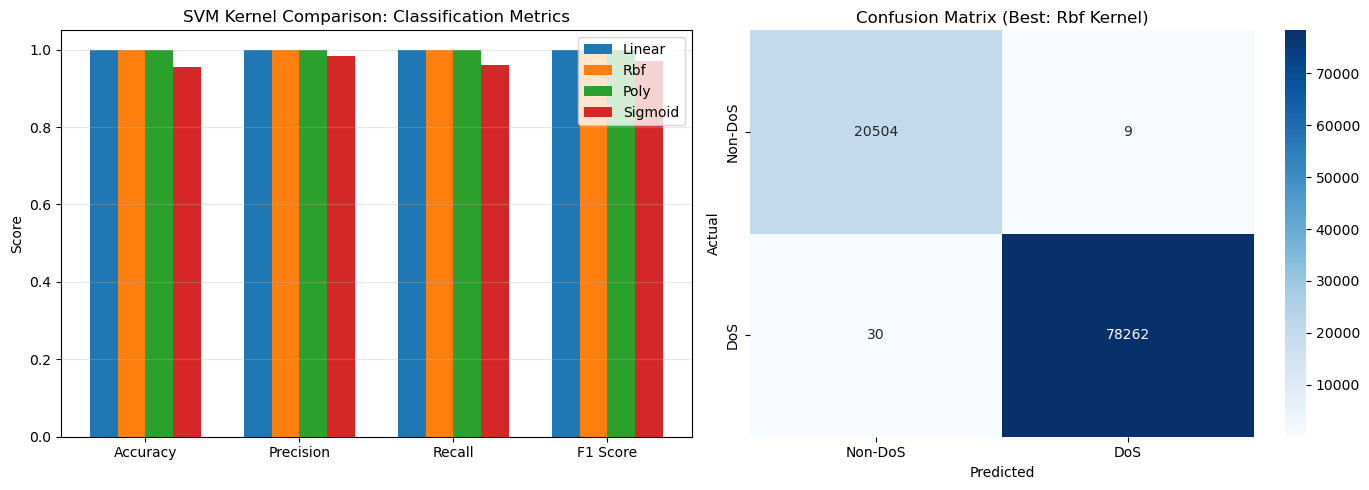


Best performing kernel by F1 Score: rbf


In [12]:
# Visualize kernel comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics))
width = 0.18

for i, (name, row) in enumerate(comparison_df.iterrows()):
    axes[0].bar(x + i * width, row.values, width, label=name.capitalize())

axes[0].set_ylabel('Score')
axes[0].set_title('SVM Kernel Comparison: Classification Metrics')
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis='y', alpha=0.3)

# Confusion matrices
best_kernel = comparison_df['F1 Score'].idxmax()
cm = confusion_matrix(y_test, results[best_kernel]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Non-DoS', 'DoS'], yticklabels=['Non-DoS', 'DoS'])
axes[1].set_title(f'Confusion Matrix (Best: {best_kernel.capitalize()} Kernel)')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('kernel_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nBest performing kernel by F1 Score: {best_kernel}")

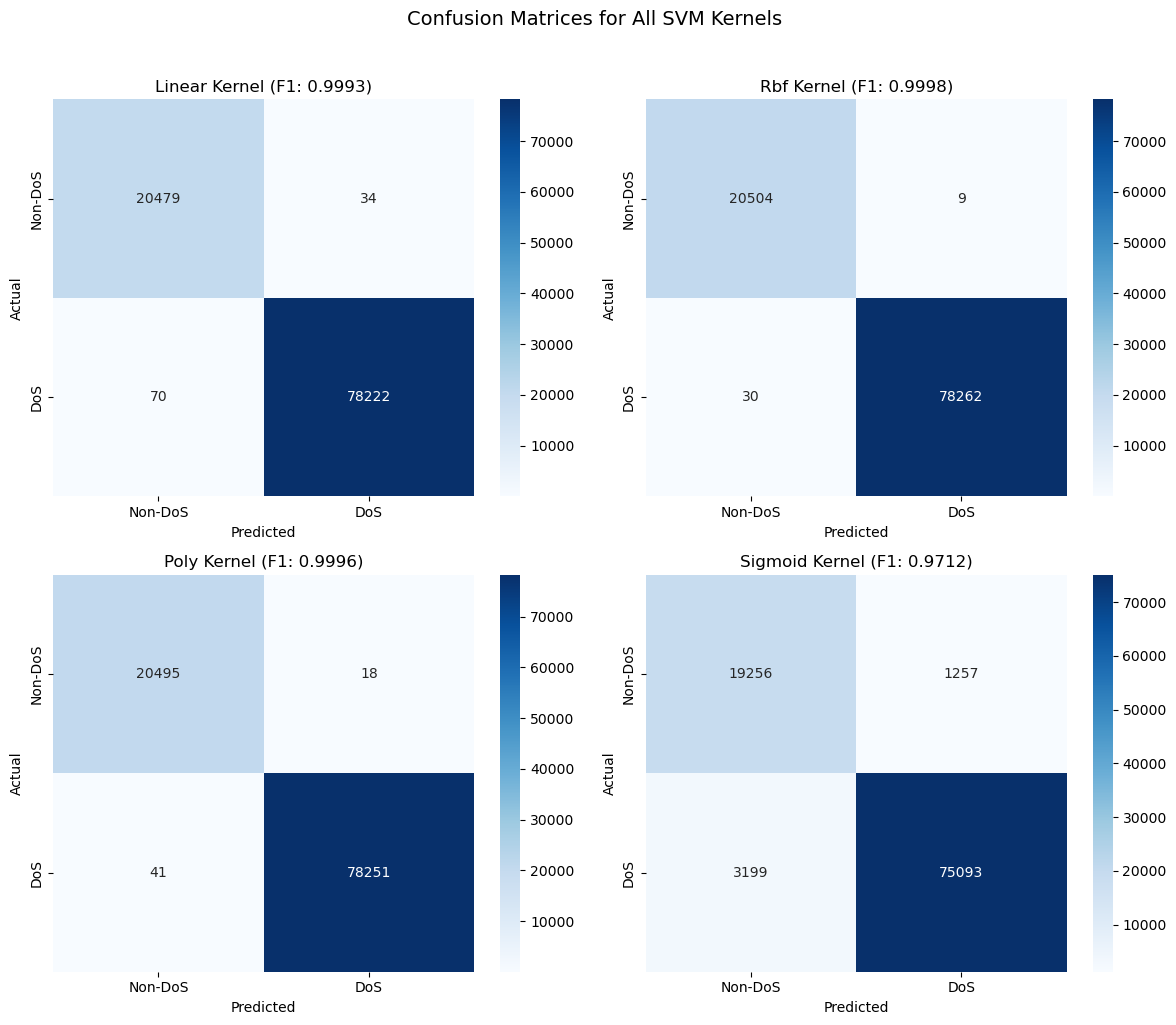

In [13]:
# Confusion matrices for all four kernels
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, (name, r) in enumerate(results.items()):
    ax = axes[idx // 2][idx % 2]
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-DoS', 'DoS'], yticklabels=['Non-DoS', 'DoS'])
    ax.set_title(f'{name.capitalize()} Kernel (F1: {r["f1_score"]:.4f})')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices for All SVM Kernels', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Detailed classification reports for each kernel
for name, r in results.items():
    print(f"\n{'='*60}")
    print(f"Classification Report: {name.upper()} Kernel")
    print(f"{'='*60}")
    print(classification_report(y_test, r['y_pred'], target_names=['Non-DoS', 'DoS']))


Classification Report: LINEAR Kernel
              precision    recall  f1-score   support

     Non-DoS       1.00      1.00      1.00     20513
         DoS       1.00      1.00      1.00     78292

    accuracy                           1.00     98805
   macro avg       1.00      1.00      1.00     98805
weighted avg       1.00      1.00      1.00     98805


Classification Report: RBF Kernel
              precision    recall  f1-score   support

     Non-DoS       1.00      1.00      1.00     20513
         DoS       1.00      1.00      1.00     78292

    accuracy                           1.00     98805
   macro avg       1.00      1.00      1.00     98805
weighted avg       1.00      1.00      1.00     98805


Classification Report: POLY Kernel
              precision    recall  f1-score   support

     Non-DoS       1.00      1.00      1.00     20513
         DoS       1.00      1.00      1.00     78292

    accuracy                           1.00     98805
   macro avg       

### Kernel comparison discussion

I tested C = 0.1, 1.0, and 10 for each kernel, and also varied gamma for RBF (scale, 0.01, 0.1). A few things stood out.

All three top kernels performed best at C=10. RBF with C=10 and gamma=scale came out on top at 0.9998 F1, followed by poly at 0.9996 and linear at 0.9993. These are all essentially perfect and the differences are tiny. Sigmoid was way behind at 0.9712 even at its best setting.

Higher C consistently helped the top three kernels. Going from C=0.1 to C=10, linear jumped from 0.9963 to 0.9993 F1, and a similar pattern showed up for RBF and poly. This makes sense since higher C means less regularization, giving the model more freedom to fit the decision boundary tightly. The fact that test performance also improved (not just training) tells me we're not overfitting at C=10 with this data.

Sigmoid was interesting because it actually got *worse* with higher C. It went from 0.9712 F1 at C=0.1 down to 0.9585 at C=10, which is the opposite of every other kernel. This is probably because the sigmoid kernel doesn't always produce a valid positive semi-definite kernel matrix, so giving it more freedom just lets it fit noise in weird ways.

For RBF, gamma mattered. The best gamma was 'scale' (which sklearn calculates as 1/(n_features * variance)), while gamma=0.01 consistently underperformed. This makes sense since gamma controls how local each support vector's influence is. Too small and the boundary is too smooth, too large and it overfits.

**Pros and cons:**

Linear is the fastest to train and basically matched the others here. It can only draw a flat hyperplane though, so it would struggle if the boundary were more complex. For this problem it works well and you get interpretability through the weight vector.

RBF was technically the best performer and handles nonlinear boundaries with the Gaussian function. The downside is it's slower and you have gamma on top of C to tune. In this case the margin over linear was only 0.0005 F1 so the extra complexity barely paid off.

Polynomial performed about the same as linear and RBF. It captures feature interactions up to the specified degree (3 here). Higher degrees can cause numerical issues and overfitting though, and it adds degree and coef0 as extra hyperparameters.

Sigmoid was clearly the weakest across all hyperparameter settings. It doesn't always satisfy Mercer's condition so it's not guaranteed to be a valid kernel, and that showed in the results.

### Two-feature decision boundary visualization

I picked `src_bytes` and `count` as the two features. DoS attacks are fundamentally about flooding a target, so `count` (connections to the same host in the last 2 seconds) should be high during a flood. `src_bytes` captures payload size which varies between attack types, like smurf sending large ICMP packets vs neptune SYN floods having minimal payload. Together these should give reasonable separation.

Subsampled to 2000 points since SVM on a mesh grid is expensive.

In [15]:
# Select two features for visualization
feature1 = 'src_bytes'
feature2 = 'count'

# Get feature indices
feature_names = list(X.columns)
f1_idx = feature_names.index(feature1)
f2_idx = feature_names.index(feature2)

print(f"Selected features for visualization:")
print(f"  Feature 1: {feature1} (index {f1_idx})")
print(f"  Feature 2: {feature2} (index {f2_idx})")

# Subsample heavily for visualization (SVM is slow + we need a clean plot)
VIS_SAMPLE = 2000
X_vis, y_vis = resample(X_train_bal, y_train_bal, 
                        n_samples=VIS_SAMPLE, random_state=42, stratify=y_train_bal)

# Extract only the two features
X_vis_2f = X_vis[[feature1, feature2]].values

# Scale the 2-feature data
scaler_2f = MinMaxScaler()
X_vis_2f_scaled = scaler_2f.fit_transform(X_vis_2f)

print(f"\nVisualization dataset: {X_vis_2f_scaled.shape[0]} samples")
print(f"  DoS: {y_vis.sum()}, Non-DoS: {(y_vis == 0).sum()}")

Selected features for visualization:
  Feature 1: src_bytes (index 4)
  Feature 2: count (index 22)

Visualization dataset: 2000 samples
  DoS: 1000, Non-DoS: 1000


In [16]:
def plot_decision_boundary(X, y, model, kernel_name, feature1_name, feature2_name, ax=None):
    """Plot SVM decision boundary for 2D feature space."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    # Create mesh grid
    h = 0.01  # step size
    x_min, x_max = X[:, 0].min() - 0.05, X[:, 0].max() + 0.05
    y_min, y_max = X[:, 1].min() - 0.05, X[:, 1].max() + 0.05
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Predict on mesh
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary and margins
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
    ax.contour(xx, yy, Z, colors='k', linewidths=0.5)
    
    # Plot data points
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, 
                        edgecolors='k', s=15, alpha=0.6)
    
    ax.set_xlabel(feature1_name + ' (scaled)')
    ax.set_ylabel(feature2_name + ' (scaled)')
    ax.set_title(f'SVM Decision Boundary ({kernel_name} Kernel)')
    
    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', 
                              markersize=8, label='Non-DoS'),
                       Line2D([0], [0], marker='o', color='w', markerfacecolor='red', 
                              markersize=8, label='DoS')]
    ax.legend(handles=legend_elements, loc='best')
    
    return ax

print("Decision boundary plotting function defined.")

Decision boundary plotting function defined.


In [17]:
# Train Linear and RBF SVMs on the two selected features
print("Training Linear SVM on 2 features...")
svm_linear_2f = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear_2f.fit(X_vis_2f_scaled, y_vis)
y_pred_linear_2f = svm_linear_2f.predict(X_vis_2f_scaled)
acc_linear = accuracy_score(y_vis, y_pred_linear_2f)
print(f"  Training accuracy: {acc_linear:.4f}")

print("\nTraining RBF SVM on 2 features...")
svm_rbf_2f = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf_2f.fit(X_vis_2f_scaled, y_vis)
y_pred_rbf_2f = svm_rbf_2f.predict(X_vis_2f_scaled)
acc_rbf = accuracy_score(y_vis, y_pred_rbf_2f)
print(f"  Training accuracy: {acc_rbf:.4f}")

Training Linear SVM on 2 features...
  Training accuracy: 0.9865

Training RBF SVM on 2 features...
  Training accuracy: 0.9855


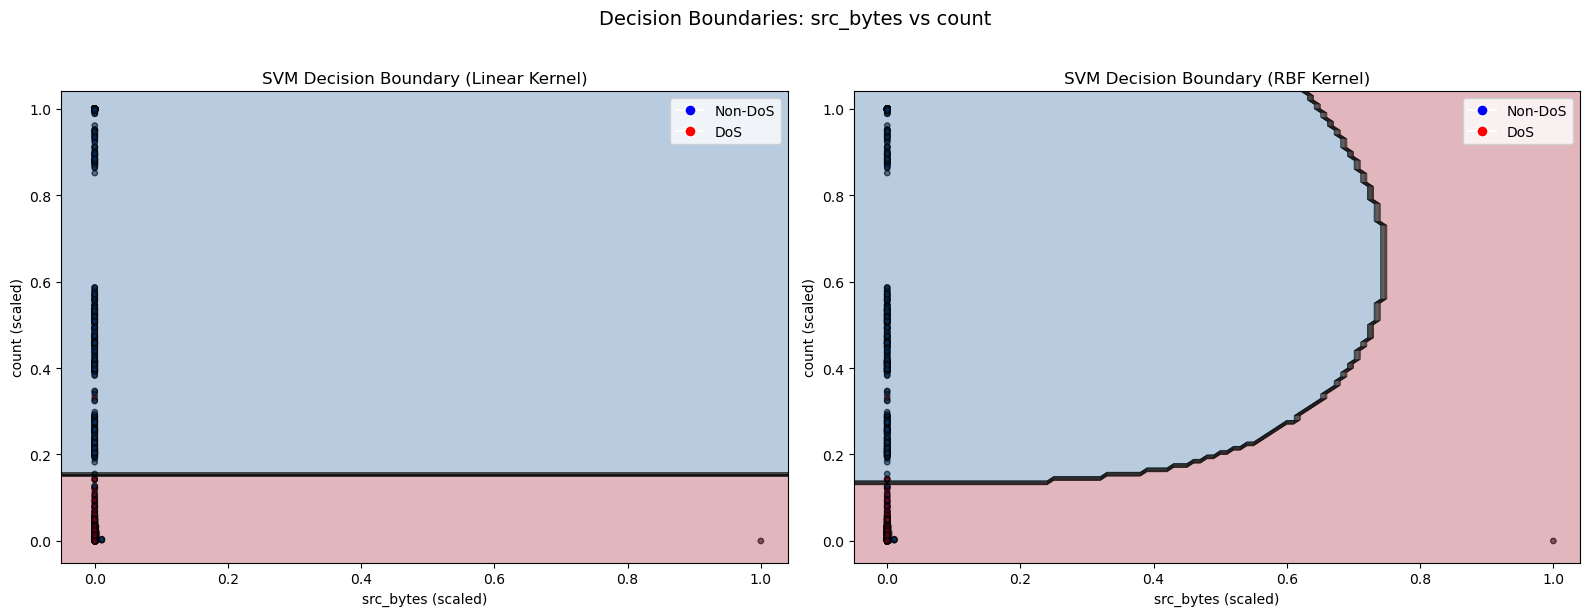

In [18]:
# Plot decision boundaries side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_decision_boundary(X_vis_2f_scaled, y_vis.values, svm_linear_2f, 
                      'Linear', feature1, feature2, ax=axes[0])

plot_decision_boundary(X_vis_2f_scaled, y_vis.values, svm_rbf_2f, 
                      'RBF', feature1, feature2, ax=axes[1])

plt.suptitle(f'Decision Boundaries: {feature1} vs {feature2}', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('decision_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()

### Decision boundary observations

Linear kernel gives a straight boundary splitting the space, RBF creates a more curved boundary that wraps around clusters.

Even with just two features both models get high training accuracy: 0.9865 for linear and 0.9855 for RBF. So src_bytes and count carry a lot of signal for this task. The accuracies being nearly identical is consistent with what we saw in the full-feature comparison where the classes are well separated even with a simple linear boundary.

RBF's boundary is more complex and can isolate smaller pockets of one class within the other, but that doesn't actually improve accuracy here. This reinforces that for DoS detection on this dataset the class separation is clean enough that you don't need nonlinear transformations.

Two features aren't enough for a real classifier though. The full 41-feature models scored above 0.999, these 2-feature models are at 0.98. Still decent but the extra features help catch edge cases.

### Conclusion

SVM works well for DoS detection on KDD99. With hyperparameter tuning, RBF with C=10 came out slightly ahead at 0.9998 F1, but linear and poly were right behind it at 0.9993 and 0.9996. The classes are separable enough that even a flat hyperplane does the job. Sigmoid was the only kernel that consistently underperformed, topping out at 0.9712.

All three top kernels benefited from higher C values, which suggests the data is clean enough that less regularization helps. For RBF, gamma='scale' worked best. Sigmoid was the odd one out, actually getting worse with higher C.

Preprocessing mattered a lot. Undersampling the 79% majority class was necessary to stop the model from just predicting DoS for everything, and MinMaxScaler helped SVM converge properly.

The decision boundary plots helped build intuition about how kernels work differently even though the performance gap was negligible. Seeing the curved RBF contour next to the straight linear boundary makes the theoretical difference concrete.